In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

In [2]:


# 1. Define the directory path
folder_path = Path("dataset/dsfsi-anv/anv")

# 2. Get all CSV files in the folder (use rglob("*.csv") to include subfolders)
csv_files = list(folder_path.glob("*.csv"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48920 entries, 0 to 48919
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   language               48920 non-null  object  
 1   split                  48920 non-null  category
 2   audio_id               48920 non-null  string  
 3   recorder_uuid          48920 non-null  string  
 4   type                   48920 non-null  category
 5   system_file_name       48920 non-null  object  
 6   file_name              48920 non-null  object  
 7   full_path              48920 non-null  object  
 8   domain                 48920 non-null  category
 9   topic                  48920 non-null  category
 10  scenario               45504 non-null  string  
 11  transcript             48920 non-null  string  
 12  duration               48920 non-null  float64 
 13  size_bytes             48920 non-null  int64   
 14  microphone_device_id   48920 non-null 

,split,audio_id,recorder_uuid,type,domain,topic,scenario,transcript,duration,size_bytes,microphone_device_id,microphone_label,signal_to_noise_ratio,document_id,source_document,audio_sampling_rate,audio_num_samples,audio_num_channels
count,48920,48920,48920,48920,48920,48920,45504,48920,48920.000000,4.892000e+04,48920,48920,48920.000000,11376,11376,48920.0,4.892000e+04,48920.0
unique,3,48920,98,2,10,653,415,40817,NaN,NaN,176,20,NaN,290,3,NaN,NaN,NaN
top,train,NBL-4ccc36ce-86f5-11f0-9afe-0242ac120003-SCR-G...,9eb56c04-475b-11f0-bec8-0242ac120004,unscripted,Health,Agricultural products and sectors,Fashion and Clothing,Bekanesiqiniseko sokuthi umloyi umloyile.,NaN,NaN,default,Default,NaN,wrdnt-48770e49-fa16-45f8-8874-c1399f9ac516,Vukuzenzele,NaN,NaN,NaN
freq,43703,1,1158,37544,9044,5281,3854,69,NaN,NaN,26824,26306,NaN,3416,6781,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.546871,1.659389e+06,NaN,NaN,42.439163,NaN,NaN,48000.0,8.422499e+05,1.0
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.972591,1.241337e+06,NaN,NaN,9.602196,NaN,NaN,0.0,6.226843e+05,0.0
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.200000,8.921000e+04,NaN,NaN,30.000000,NaN,NaN,48000.0,5.760000e+04,1.0
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.250901,7.675660e+05,NaN,NaN,34.990000,NaN,NaN,48000.0,3.960432e+05,1.0
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.944563,1.309292e+06,NaN,NaN,40.550000,NaN,NaN,48000.0,6.693390e+05,1.0
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.864922,2.167676e+06,NaN,NaN,47.380000,NaN,NaN,48000.0,1.097516e+06,1.0


## Now viewing: **split**

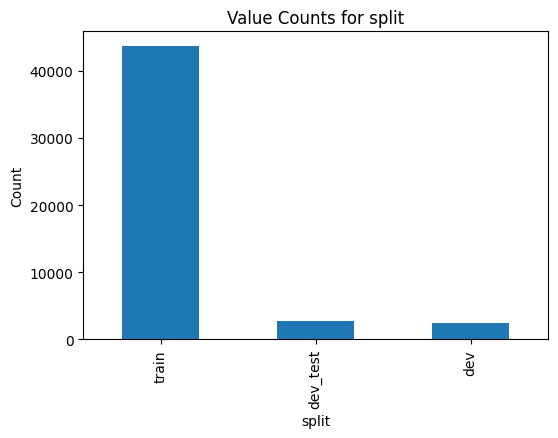

## Now viewing: **recorder_uuid**

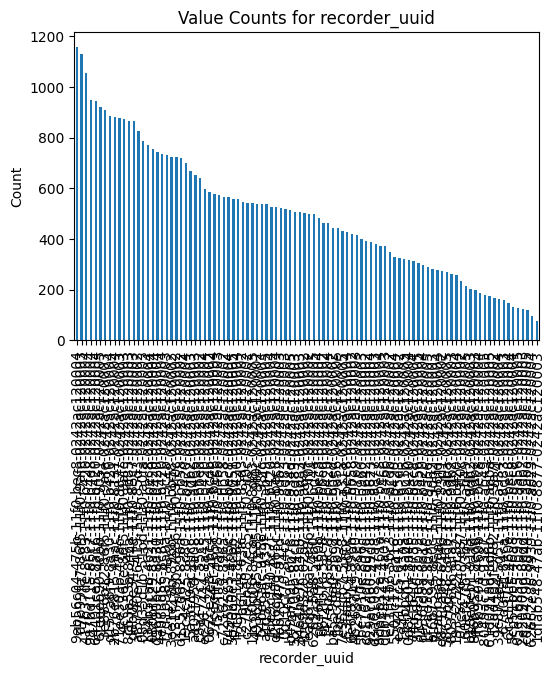

## Now viewing: **type**

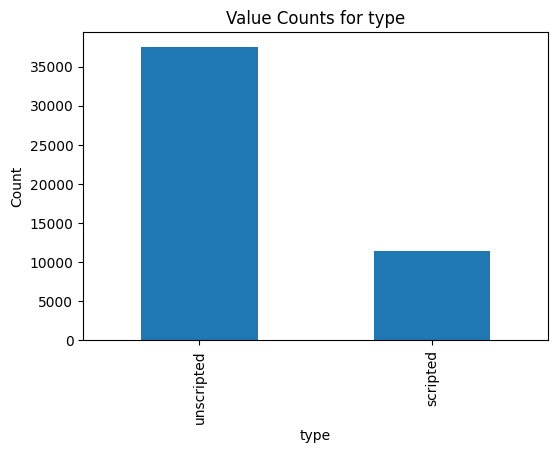

## Now viewing: **domain**

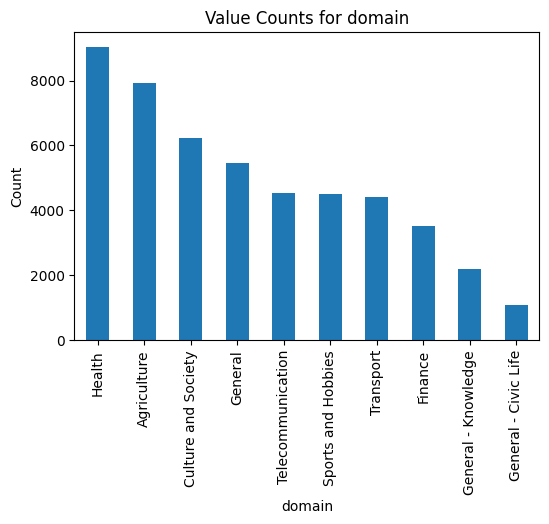

## Now viewing: **topic**

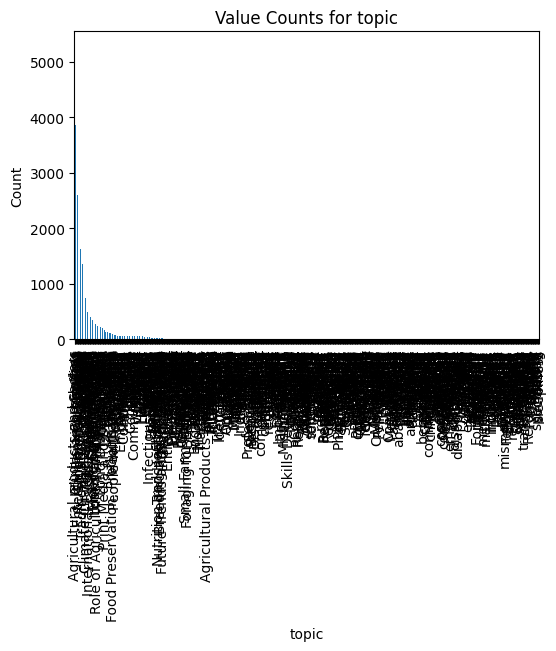

## Now viewing: **scenario**

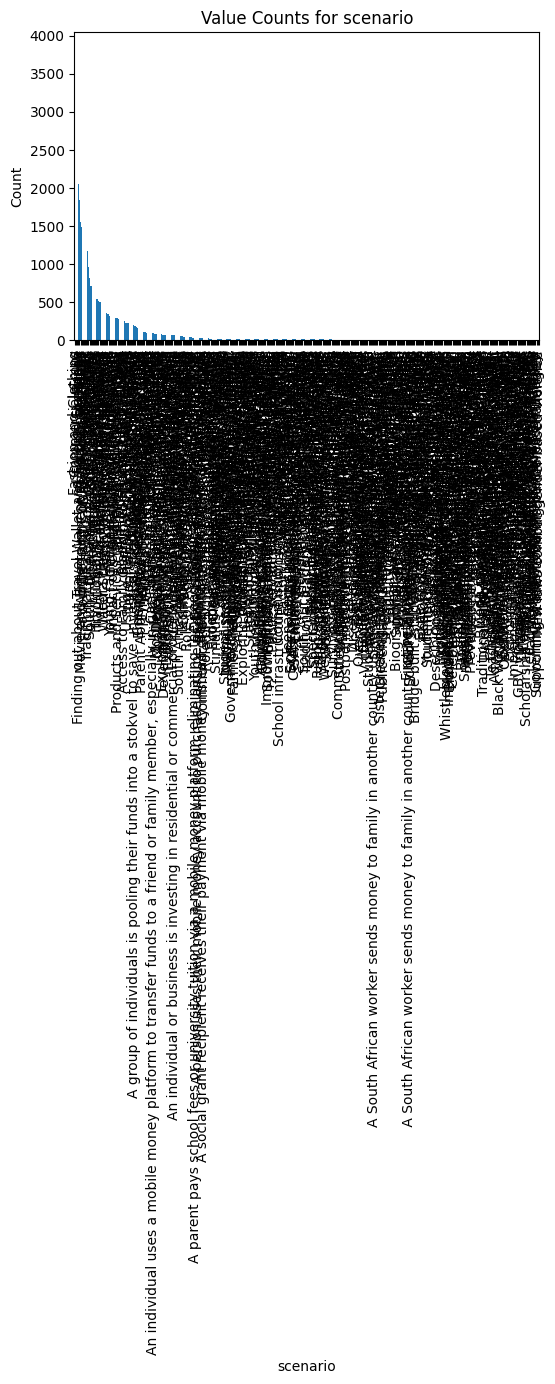

## Now viewing: **duration**

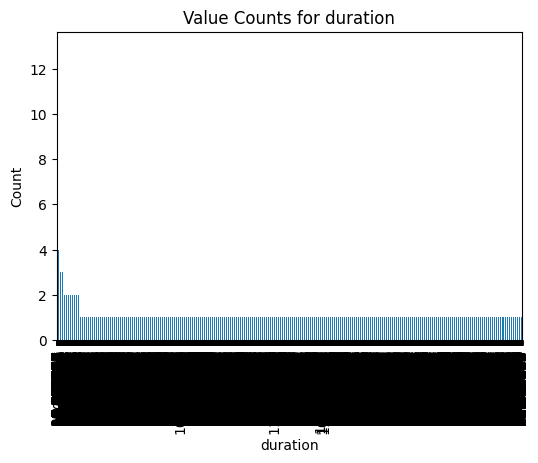

## Now viewing: **size_bytes**

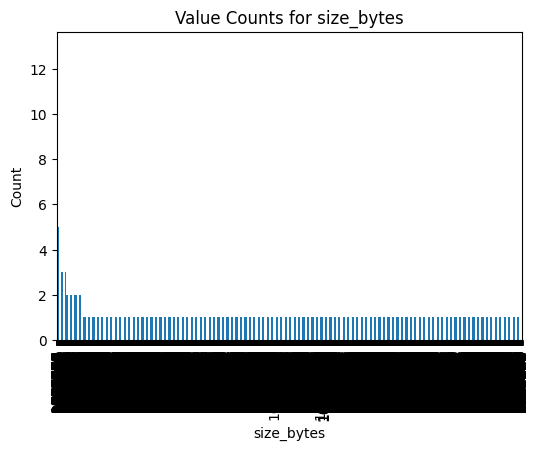

## Now viewing: **microphone_device_id**

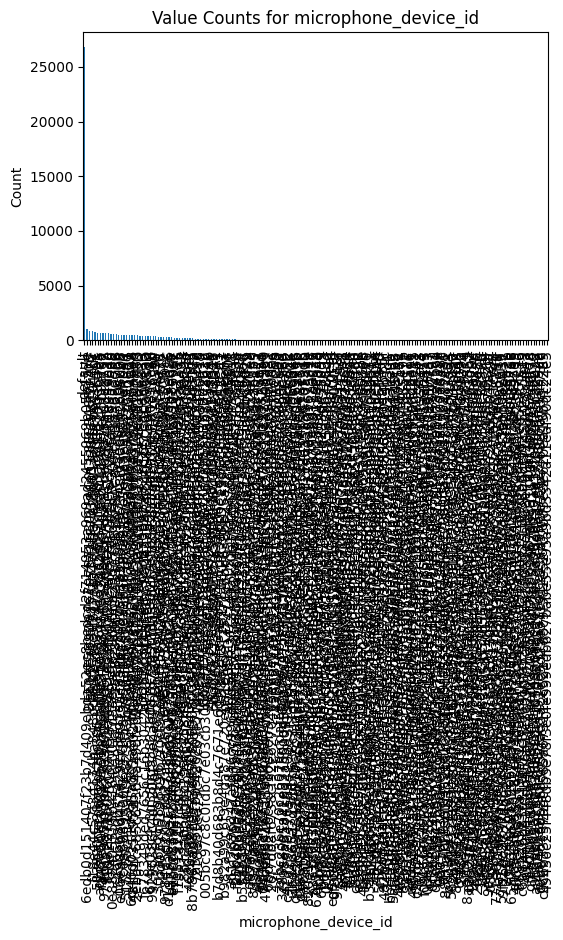

## Now viewing: **microphone_label**

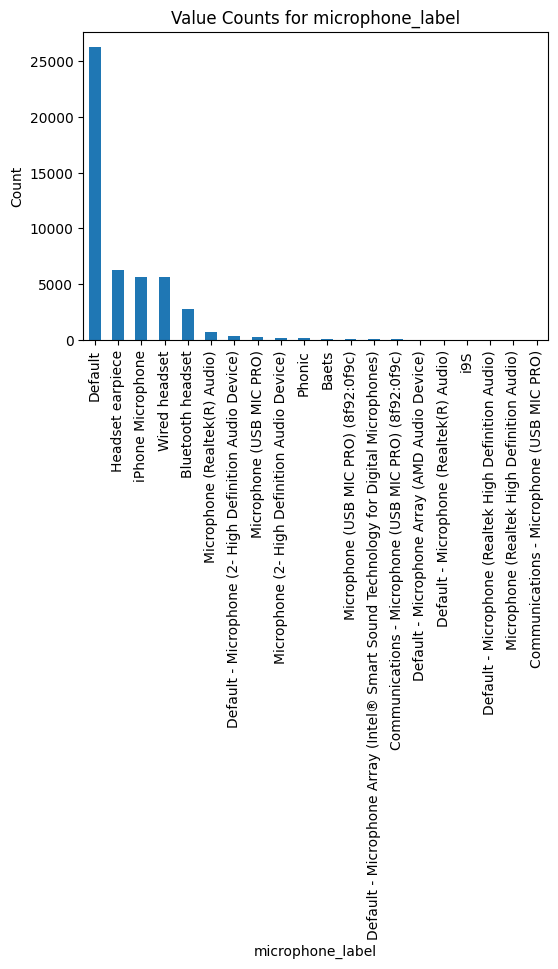

## Now viewing: **signal_to_noise_ratio**

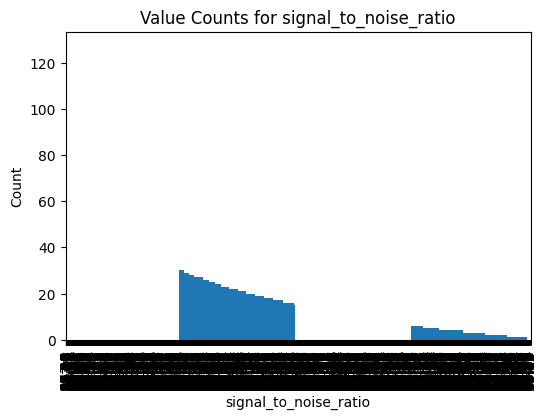

## Now viewing: **document_id**

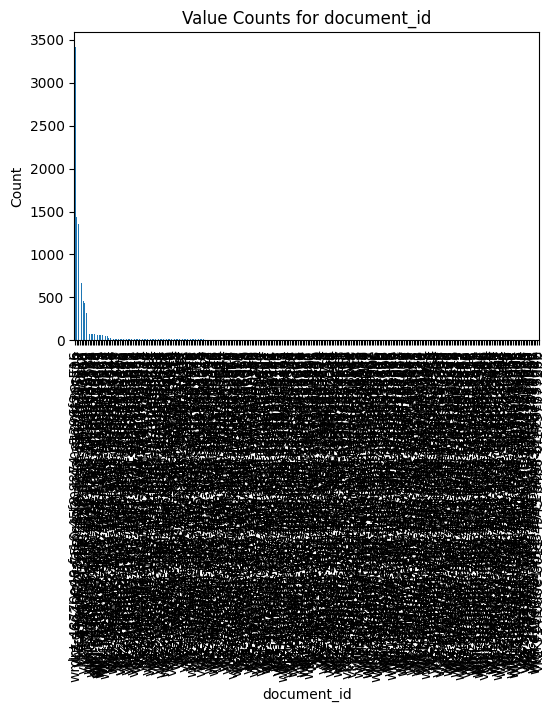

## Now viewing: **source_document**

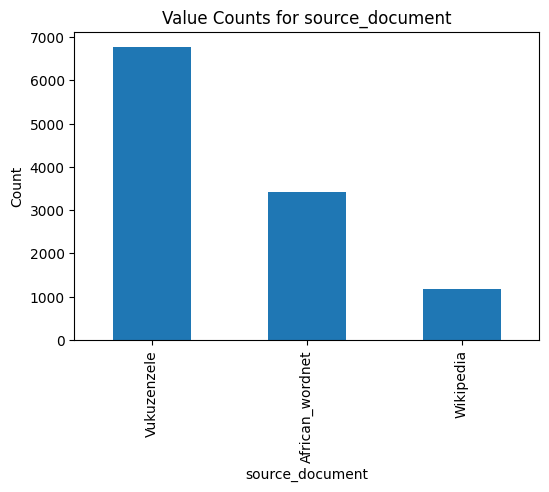

## Now viewing: **audio_sampling_rate**

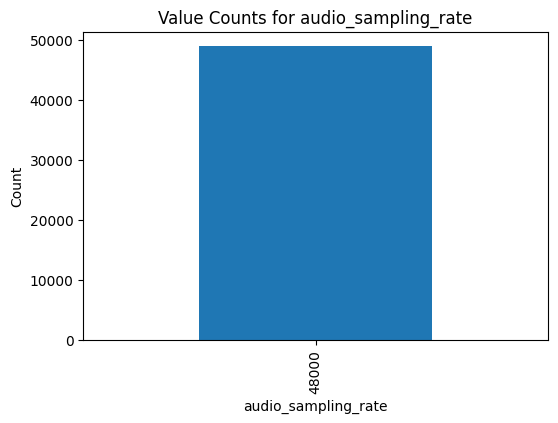

## Now viewing: **audio_num_samples**

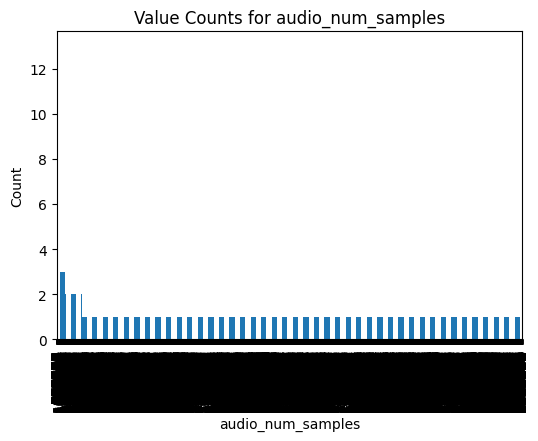

## Now viewing: **audio_num_channels**

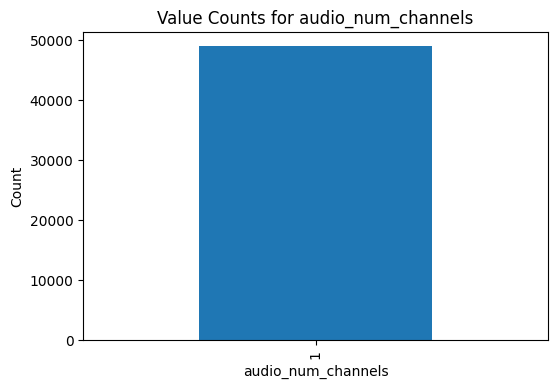

In [3]:
for file in csv_files[:1]:
    df = pd.read_csv(csv_files[0])

    #display(df.head(5))


    df = df.astype({"split":'category','audio_id':'string','recorder_uuid':'string'},)
    df = df.astype({'type':'category','domain':'category','topic':'category',})
    df = df.astype({'scenario':'string','transcript':'string','document_id':'string','source_document':'category'})
    df = df.astype({'microphone_device_id':'string','microphone_label':'category'})

    df.info()

    drop_display_coloumns = ['language','system_file_name','file_name','full_path']
    display(df.drop(columns=drop_display_coloumns).describe(include='all'))
    #drop_coloums = ['langauge','system_file_name','file_name','full_path']

    drop_display_coloumns = ['language','audio_id','transcript','system_file_name','file_name','full_path',]
    for col in df.drop(columns=drop_display_coloumns).columns:
        # Use display() combined with Markdown()
        display(Markdown(f"## Now viewing: **{col}**"))

        plt.figure(figsize=(6, 4))
        df[col].value_counts().plot(kind="bar")
        plt.title(f"Value Counts for {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.show()

    